# Diversity

In [ ]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision.transforms import v2
from tqdm import tqdm
from scipy.spatial.distance import pdist

model = torch.hub.load("facebookresearch/dinov2", "dinov2_vitl14")
device = "cuda:0"
model.eval().requires_grad_(False).to(device)
preprocess = v2.Compose(
    [
        v2.Resize((512, 512)),
        v2.Resize((224, 224)),
        v2.ToTensor(),
        v2.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

# exp = "tb-sd21base-n1-fc2-100"
exp = "tb-sd21base-n1-expand-80"
# exp = "tb-sd21base-n1-final-100"
# exp = "tb-sd14-n1-final-80"
# exp = "tb-sd15-n1-ur1-80"

instances = os.listdir(f"../images/{exp}/seed0")

scores = []
for instance in instances:
    prompts = os.listdir(f"../images/{exp}/seed0/{instance}")

    for prompt in prompts:
        images = []
        for seed in range(4):
            seed_path = f"../images/{exp}/seed{seed}/{instance}/{prompt}"
            image = Image.open(seed_path)
            image = preprocess(image).unsqueeze(0).to(device)
            images.append(image)
        images = torch.cat(images, dim=0)
        image_features = model(images.to(device)).float().cpu().numpy()
        dist = pdist(image_features, metric="cosine").mean()
        # print(prompt, dist)
        scores.append(dist)

# print(np.mean(scores), np.std(scores))
print(f"Mean: {np.mean(scores):.3f}")

Using cache found in /home/kunkim/.cache/torch/hub/facebookresearch_dinov2_main


Mean: 0.229


In [22]:
import torch
from diffusers.utils import make_image_grid
from textboost.utils import load_pipeline_from_checkpoint

pipeline, identifier = load_pipeline_from_checkpoint(
    "stabilityai/stable-diffusion-2-1-base",
    "../output/tb-sd21base-n1-ti_no_expand/cat2/checkpoint-100",
)
pipeline.to("cuda:3", dtype=torch.float16)

Expected types for text_encoder: ['CLIPTextModel'], got TextModel.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 38.53it/s]


Loaded learned embeddings from checkpoint.
['<cat2>']


TextBoostPipeline {
  "_class_name": "TextBoostPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "stabilityai/stable-diffusion-2-1-base",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "textboost.text_encoder",
    "TextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

100%|██████████| 50/50 [00:02<00:00, 21.44it/s]


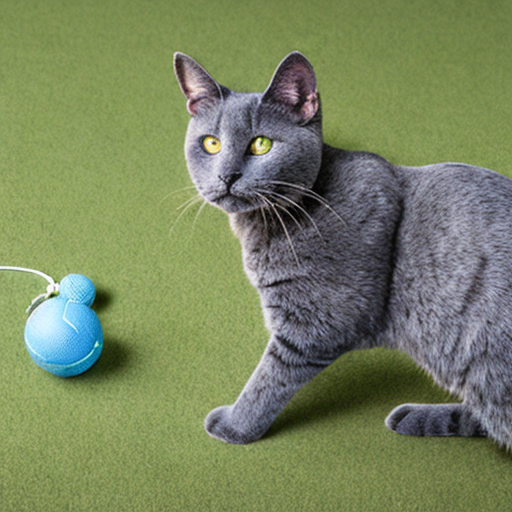

In [106]:
generator = torch.Generator(device="cuda:3").manual_seed(78)
images = pipeline(
    prompt="a <cat2> playing with a ball in the grass",
    # num_images_per_prompt=4,
    generator=generator,
).images

# print(len(images))
# images = [image.resize((512, 512)) for image in images]
# grid = make_image_grid(images, 2, 2)
# grid
# 11, 15, 53
images[0]